# Portfolio Drift Monitor — Project Pipeline

**The spine of the project.** Started in Stage 04 and extended by every stage
that follows. Each stage appends a section; the whole notebook is re-run top to
bottom before every commit, so "the earlier stages still work" is verified
rather than assumed.

| Stage | Section below |
|---|---|
| 04 Data Acquisition | ingest VTI / VXUS / BND, validate, save to `data/raw/` |
| 05 Data Storage | *(added next stage)* |

**Run order matters.** Cells below assume the ones above have run in sequence.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')                               # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))                # so `from src....` imports work
print('working from:', ROOT.name)

working from: project


In [2]:
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from src.utils import TARGET_WEIGHTS, to_weights, drift_pp, flag_drift

load_dotenv()
RAW = Path(os.getenv('DATA_DIR_RAW', 'data/raw'))
PROC = Path(os.getenv('DATA_DIR_PROCESSED', 'data/processed'))
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

print('RAW  ->', RAW)
print('PROC ->', PROC)
print('targets:', TARGET_WEIGHTS)

RAW  -> data/raw
PROC -> data/processed
targets: {'VTI': 0.6, 'VXUS': 0.3, 'BND': 0.1}


---

## Stage 04 — Data Acquisition & Ingestion

Daily closes for the three funds in the model portfolio, pulled from yfinance
and saved to `data/raw/` under a timestamped filename. Nothing here edits an
existing file: a re-run adds a new one, so any earlier state stays recoverable.

**Why raw `close` and not adjusted close.** Adjusted close is a paid field at
Alpha Vantage, so the ingestion path that survives vendor changes is the one
that never assumed the column existed. The cost is that dividends and splits are
not reflected — fine for short-window weight drift, wrong for long-horizon
returns, and stated here so it cannot be forgotten downstream.

In [3]:
TICKERS = list(TARGET_WEIGHTS.keys())        # VTI, VXUS, BND
PERIOD = '1y'


def ingest_prices(tickers, period=PERIOD):
    # Returns a long frame: one row per (date, ticker).
    import yfinance as yf
    raw = yf.download(tickers, period=period, interval='1d',
                      auto_adjust=False, progress=False)

    # Code against the SHAPE that comes back, not the shape we remember:
    # yfinance returns a MultiIndex for multi-ticker requests and a flat one
    # for a single ticker, and the level order has changed between versions.
    close = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']]
    if not isinstance(raw.columns, pd.MultiIndex):
        close.columns = tickers

    out = (close.reset_index()
                .melt(id_vars='Date', var_name='ticker', value_name='close')
                .rename(columns={'Date': 'date'})
                .dropna(subset=['close'])
                .sort_values(['date', 'ticker'])
                .reset_index(drop=True))
    out['date'] = pd.to_datetime(out['date'])
    out['close'] = pd.to_numeric(out['close'])
    return out


prices_long = ingest_prices(TICKERS)
print(prices_long.shape)
prices_long.head()

(750, 3)


,date,ticker,close
0,2025-08-29,BND,73.800003
1,2025-08-29,VTI,318.200012
2,2025-08-29,VXUS,71.370003
3,2025-09-02,BND,73.400002
4,2025-09-02,VTI,315.989990


In [4]:
def validate_prices(df, tickers):
    # Schema, types, completeness, sanity - the four checks from Stage 04.
    checks = {
        'required_cols': all(col in df.columns for col in ['date', 'ticker', 'close']),
        'date_is_datetime': pd.api.types.is_datetime64_any_dtype(df['date']),
        'close_is_numeric': pd.api.types.is_numeric_dtype(df['close']),
        'all_tickers_present': set(tickers) == set(df['ticker'].unique()),
        'na_total': int(df.isna().sum().sum()),
        'duplicate_rows': int(df.duplicated(subset=['date', 'ticker']).sum()),
        'all_prices_positive': bool((df['close'] > 0).all()),
        'rows_per_ticker': df.groupby('ticker').size().to_dict(),
    }
    return checks


checks = validate_prices(prices_long, TICKERS)
for key, value in checks.items():
    print(f"{key:<22} {value}")

required_cols          True
date_is_datetime       True
close_is_numeric       True
all_tickers_present    True
na_total               0
duplicate_rows         0
all_prices_positive    True
rows_per_ticker        {'BND': 250, 'VTI': 250, 'VXUS': 250}


In [5]:
# Fail loudly rather than saving something malformed.
assert checks['required_cols'],        'missing required columns'
assert checks['all_tickers_present'],  'a ticker is missing from the pull'
assert checks['all_prices_positive'],  'non-positive price'
assert checks['duplicate_rows'] == 0,  'duplicate (date, ticker) rows'
assert checks['na_total'] == 0,        'unexpected missing values'
print('validation passed')

validation passed


In [6]:
def ts():
    return dt.datetime.now().strftime('%Y%m%d-%H%M')


raw_path = RAW / f"api_yfinance_{'-'.join(TICKERS)}_{ts()}.csv"
prices_long.to_csv(raw_path, index=False)
print('saved', raw_path, f'({len(prices_long)} rows)')

saved data/raw/api_yfinance_VTI-VXUS-BND_20260829-1203.csv (750 rows)


---

## Stage 06 - Cleaning, between raw and processed

Raw is what the vendor said. Processed is what I am willing to compute on. Cleaning is the
boundary between the two, so it belongs exactly here: after the raw file is written to disk,
before a single weight is calculated.

`src/cleaning.py` deliberately does **not** reuse the median rule from
`homework/homework06/src/cleaning.py`. That module cleans a cross-section of seven unrelated
people, where the column median is a fair stand-in for a blank. This is a time series, where
it is not. The median of a year of VTI closes is not a plausible price for any particular
Tuesday, and substituting it would invent a move the market never made. Here a missing close
is carried forward from the last observation, capped at three days, and anything longer stays
visible and gets dropped.

**The order of operations, and why it is not interchangeable:**

1. **Coerce types.** The raw file is CSV, and Stage 05 established that CSV is text and
   forgets dtypes. Everything below depends on `date` being a real datetime and `close` a
   real float.
2. **Sort by (date, ticker).** Forward fill walks the frame in row order. On an unsorted
   frame it propagates prices *backwards* through time.
3. **Drop duplicate (date, ticker).** Before filling, so a duplicate cannot become the source
   of a fill for its own twin. `keep='last'`, on the assumption that a resent day is a
   correction - which is an assumption about the vendor, not a fact.
4. **Non-positive closes to missing.** A close of zero is not a cheap fund, it is a broken
   record.
5. **Forward fill, limit three days.** A long weekend plus a holiday. Filling further draws a
   flat line through the gap, and a flat line is a positive claim of zero volatility, not an
   absence of data.
6. **Drop incomplete days.** Last, because step 5 may have repaired a day that was incomplete
   when it arrived.

In [7]:
from src import cleaning

# Clean what was actually persisted, not what happens to still be in memory. Reloading is the
# only way to show the file on disk is usable - and it is what tomorrow's run will do.
raw_reloaded = pd.read_csv(raw_path)

print('reloaded', raw_path.name, raw_reloaded.shape)
print()
print(cleaning.missingness_report(raw_reloaded).to_string())

reloaded api_yfinance_VTI-VXUS-BND_20260829-1203.csv (750, 3)

          dtype  missing  missing_pct
date     object        0          0.0
ticker   object        0          0.0
close   float64        0          0.0


In [8]:
prices_clean, clean_log = cleaning.clean_prices(raw_reloaded, TICKERS)

for key, value in clean_log.items():
    print(f'{key:<28} {value}')

rows_in                      750
unparseable_values           {'date': 0, 'close': 0}
duplicate_rows_removed       0
non_positive_prices          0
missing_closes_before_fill   0
closes_forward_filled        0
incomplete_days_dropped      0
dropped_dates                []
rows_out                     750
rows_removed                 0


Every counter is zero: today's pull needed nothing done to it. That is the expected result for
one vendor on three of the most liquid funds listed, and it is also the least informative test
available. **A cleaning step that has never changed a number is indistinguishable from one
that cannot.** So the next cell breaks a copy on purpose and checks that the same code repairs
it.

In [9]:
# Five faults, one of each kind the module claims to handle.
dates = sorted(raw_reloaded['date'].unique())
d_nan, d_zero, gap = dates[20], dates[35], dates[50:54]

damaged = raw_reloaded.copy()
damaged['date'] = damaged['date'].astype(str)                                        # 1. dtypes lost
damaged.loc[(damaged['date'] == d_nan) & (damaged['ticker'] == 'VXUS'), 'close'] = np.nan   # 2. missed close
damaged.loc[(damaged['date'] == d_zero) & (damaged['ticker'] == 'VTI'), 'close'] = 0.0      # 3. broken record
damaged = pd.concat([damaged,
                     damaged[(damaged['date'] == dates[5]) &
                             (damaged['ticker'] == 'BND')]], ignore_index=True)      # 4. vendor resend
damaged = damaged[~((damaged['date'].isin(gap)) & (damaged['ticker'] == 'BND'))]     # 5. a fund absent 4 days
damaged = damaged.sample(frac=1, random_state=6).reset_index(drop=True)              #    and out of order

damaged_clean, damaged_log = cleaning.clean_prices(damaged, TICKERS)

for key, value in damaged_log.items():
    print(f'{key:<28} {value}')

rows_in                      747
unparseable_values           {'date': 0, 'close': 0}
duplicate_rows_removed       1
non_positive_prices          1
missing_closes_before_fill   2
closes_forward_filled        2
incomplete_days_dropped      4
dropped_dates                ['2025-11-10', '2025-11-11', '2025-11-12', '2025-11-13']
rows_out                     738
rows_removed                 9


In [10]:
# Does the repaired frame match the series already known to be true?
truth = prices_clean[~prices_clean['date'].isin(pd.to_datetime(gap))]
merged = damaged_clean.merge(truth, on=['date', 'ticker'], suffixes=('_repaired', '_true'))

print('rows compared  :', len(merged))
print('rows identical :', int(np.isclose(merged['close_repaired'], merged['close_true']).sum()))

differs = merged[~np.isclose(merged['close_repaired'], merged['close_true'])].copy()
differs['error_bps'] = (differs['close_repaired'] / differs['close_true'] - 1) * 1e4
print()
print('the forward-filled cells, and what the fill cost:')
print(differs.round(2).to_string(index=False))

rows compared  : 738
rows identical : 736

the forward-filled cells, and what the fill cost:
      date ticker  close_repaired  close_true  error_bps
2025-09-29   VXUS           72.75       73.14     -53.32
2025-10-20    VTI          327.30      330.95    -110.29


The repair is exact everywhere except the two cells that were forward-filled, and those are
wrong by roughly half a percent - the size of one day's move in a broad equity fund, which is
precisely what a one-day-stale price is. The error is small, it is bounded by the fill limit,
and it is in the log rather than hidden. That is the trade the fill makes, stated in basis
points instead of adjectives.

The four days where BND was absent entirely are gone rather than repaired, and the next cell
is the argument for why.

In [11]:
# What would keeping an incomplete day have done to the report Dana opens?
day = pd.Timestamp(gap[0])
wide_chk = prices_clean.pivot(index='date', columns='ticker', values='close')[TICKERS]
tgt = [TARGET_WEIGHTS[t] for t in TICKERS]

shares_chk = (1_000_000 * np.array(tgt)) / wide_chk.iloc[0].to_numpy()
vals = wide_chk.loc[day].to_numpy() * shares_chk

honest = vals / vals.sum()                                    # all three funds present
partial = np.where(np.array(TICKERS) == 'BND', 0.0, vals)     # BND silently absent
partial = partial / partial.sum()

counterfactual = pd.DataFrame({
    'fund': TICKERS,
    'weight_if_BND_missing': partial,
    'true_weight': honest,
    'drift_pp_if_missing': drift_pp(partial, tgt),
    'true_drift_pp': drift_pp(honest, tgt),
})
counterfactual['flag_if_missing'] = flag_drift(counterfactual['drift_pp_if_missing'])
counterfactual['true_flag'] = flag_drift(counterfactual['true_drift_pp'])
counterfactual.round(3)

,fund,weight_if_BND_missing,true_weight,drift_pp_if_missing,true_drift_pp,flag_if_missing,true_flag
0,VTI,0.667,0.603,6.664,0.259,red,green
1,VXUS,0.333,0.301,3.336,0.133,amber,green
2,BND,0.000,0.096,-10.000,-0.392,red,green


Read `flag_if_missing` against `true_flag`. One absent fund on one day puts VTI at about 67%
against a 60% target - a drift near 6.7pp and a **red** flag - on a day when the portfolio was
in fact within a fraction of a point of target and unambiguously green. The arithmetic is not
a coincidence and does not depend on the window: drop a 10% sleeve and the remaining weights
are divided by 0.9, which lifts a 60% target to 66.7% on its own.

That connects directly to the finding recorded at the end of Stage 05. On a year of real
closes the 5pp red threshold **never fires**. This cell shows that the only way this monitor
*would* have produced a red flag over that year is a hole in the data. An alert that fires
only on bad data is worse than no alert at all: it teaches Dana that red means "ignore this,
the file is broken", which is exactly the reflex a risk control cannot afford.

So `drop_incomplete_days` drops rather than fills, and it is the one rule in the module with
no configurable alternative. Weights computed on a partial day are not missing, they are
**wrong** - and wrong in a way that looks entirely reasonable on the report.

**What this cleaning costs, honestly.** On today's data, nothing: every counter is zero and
`prices_clean` is row-for-row the raw pull. On damaged data it costs the four dropped days
(about 1.6% of a one-year window) and two forward-filled closes carrying roughly 50 to 110 bps
of error each. The dropped days are the expensive half and the defensible one. The forward
fills are the cheap half and the one to watch: they are estimates wearing the same dtype as
observations, and nothing downstream can tell them apart once the log scrolls past. A
`close_was_filled` indicator column is the obvious Stage 09 feature, and it is not here yet.

In [12]:
from src.utils import write_df, read_df

# The cleaned price table is an artifact in its own right: it is what every later stage starts
# from, and saving it means Stage 07 does not have to re-download to reproduce Stage 06.
clean_path = write_df(prices_clean, PROC / f'prices_clean_{ts()}.parquet')
print('saved', clean_path, f'({len(prices_clean)} rows)')

back = read_df(clean_path)
assert back.shape == prices_clean.shape,                     'round trip changed the shape'
assert pd.api.types.is_datetime64_any_dtype(back['date']),   'date came back as text'
assert np.allclose(back['close'], prices_clean['close']),    'closes changed'
print('round trip verified')

saved data/processed/prices_clean_20260829-1203.parquet (750 rows)
round trip verified


### From raw prices to the report

The Stage 03 helpers now run on real data instead of simulated data, unchanged.
That was the test: if `to_weights`, `drift_pp` and `flag_drift` needed editing
to accept real input, they were written at the wrong level of abstraction.

Share counts are set so the portfolio sat exactly on target on the **first day
of the window**. Every deviation since is price movement alone — no deposits,
no withdrawals, no rebalancing.

In [13]:
# Built from prices_clean, not prices_long: nothing downstream touches raw.
wide = prices_clean.pivot(index='date', columns='ticker', values='close')[TICKERS]

PORTFOLIO_VALUE = 1_000_000
targets = np.array([TARGET_WEIGHTS[t] for t in TICKERS])
shares = (PORTFOLIO_VALUE * targets) / wide.iloc[0].to_numpy()

values = wide.to_numpy() * shares
weights = values / values.sum(axis=1, keepdims=True)

# Day 0 is on target by construction - assert it, do not assume it.
assert np.allclose(weights[0], targets), 'day 0 should sit exactly on target'
print(f"window: {wide.index.min().date()} to {wide.index.max().date()}  ({len(wide)} trading days)")

window: 2025-08-29 to 2026-08-27  (250 trading days)


In [14]:
latest = weights[-1]

report = pd.DataFrame({
    'fund': TICKERS,
    'target_weight': targets,
    'current_weight': latest,
    'drift_pp': drift_pp(latest, targets),
})
report['flag'] = flag_drift(report['drift_pp'])
report.round(4)

,fund,target_weight,current_weight,drift_pp,flag
0,VTI,0.6,0.6054,0.5353,green
1,VXUS,0.3,0.3117,1.1743,green
2,BND,0.1,0.0829,-1.7096,green


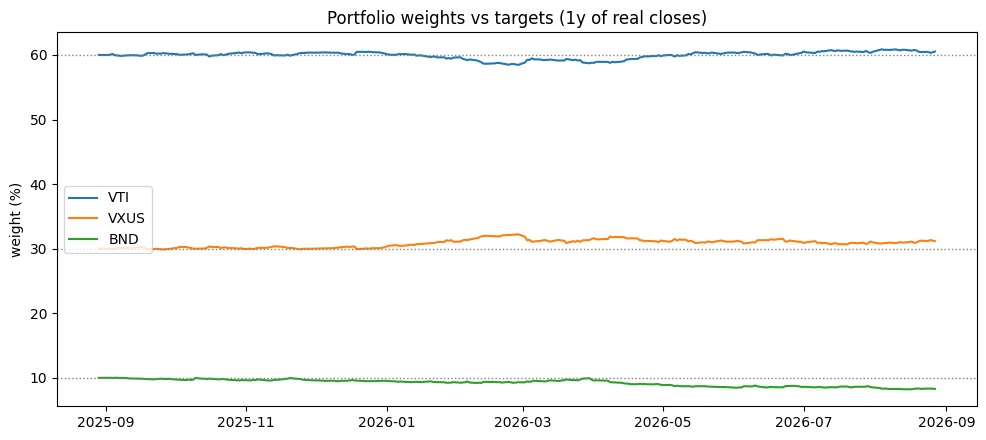

In [15]:
weights_df = pd.DataFrame(weights, index=wide.index, columns=TICKERS)

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, ticker in enumerate(TICKERS):
    ax.plot(weights_df.index, weights_df[ticker] * 100, label=ticker)
    ax.axhline(targets[i] * 100, linestyle=':', linewidth=1, color='grey')

ax.set_title(f'Portfolio weights vs targets ({PERIOD} of real closes)')
ax.set_ylabel('weight (%)')
ax.legend(loc='center left')
fig.tight_layout()
plt.show()

### Sources, parameters and validations

| | |
|---|---|
| Source | yfinance daily closes for VTI, VXUS, BND |
| Parameters | `period='1y'`, `interval='1d'`, `auto_adjust=False` |
| Secrets | `.env` (`DATA_DIR_RAW`, `DATA_DIR_PROCESSED`, `ALPHAVANTAGE_API_KEY`); never committed |
| Output | `data/raw/api_yfinance_VTI-VXUS-BND_<YYYYMMDD-HHMM>.csv` |
| Validation | required columns · dtypes · all tickers present · no NAs · no duplicate (date, ticker) · all prices positive · row counts per ticker |

**Assumptions and risks**

- **Raw close, not adjusted** — dividends and splits are not reflected. Fine for
  weight drift over a one-year window; wrong for computing total return.
- **Prices only.** Weights ignore accrued dividends and any cash sleeve.
- **The model portfolio, not a client account.** No deposits or withdrawals, so
  drift here is a pure price effect. A real account will differ.
- **Vendor dependence.** yfinance is an unofficial wrapper around a public
  endpoint and can break without notice. The shape check on the returned
  columns is deliberate, not defensive noise.
- **Re-running produces a new file** rather than overwriting, which is what
  makes an earlier pull reproducible — at the cost of a growing `data/raw/`.

**Next stage (05):** save a processed table to `data/processed/` in Parquet,
add `write_df` / `read_df` utilities, and append a Data Storage section to the
project README.

---

## Stage 05 — Data Storage

The daily report is a **derived** table: every value in it is recomputed from
`data/raw/` by the code above. So it belongs in `data/processed/`, and it is
saved as **Parquet** rather than CSV — the frame carries a datetime index and
a categorical flag, and CSV would return both as text.

`write_df` and `read_df` now live in `src/utils.py`, so the pipeline and the
homework share one definition rather than two copies that drift apart.

In [16]:
from src.utils import write_df, read_df

# The processed table: one row per (date, fund), with drift and flag.
processed = (weights_df
             .reset_index()
             .melt(id_vars='date', var_name='fund', value_name='current_weight'))
processed['target_weight'] = processed['fund'].map(TARGET_WEIGHTS)
processed['drift_pp'] = drift_pp(processed['current_weight'], processed['target_weight'])
processed['flag'] = flag_drift(processed['drift_pp'])

print(processed.shape)
processed.head()

(750, 6)


,date,fund,current_weight,target_weight,drift_pp,flag
0,2025-08-29,VTI,0.600000,0.6,0.000000,green
1,2025-09-02,VTI,0.599919,0.6,-0.008121,green
2,2025-09-03,VTI,0.600358,0.6,0.035780,green
3,2025-09-04,VTI,0.601512,0.6,0.151162,green
4,2025-09-05,VTI,0.599604,0.6,-0.039599,green


In [17]:
proc_path = write_df(processed, PROC / f"weights_drift_{ts()}.parquet")
print('saved', proc_path)

saved data/processed/weights_drift_20260829-1203.parquet


In [18]:
# Verify the round trip rather than assuming it.
back = read_df(proc_path)
checks = {
    'shape_equal': processed.shape == back.shape,
    'date_is_datetime': pd.api.types.is_datetime64_any_dtype(back['date']),
    'drift_is_numeric': pd.api.types.is_numeric_dtype(back['drift_pp']),
    'values_match': bool(np.allclose(processed['drift_pp'], back['drift_pp'])),
    'flags_match': bool((processed['flag'] == back['flag']).all()),
}
for key, value in checks.items():
    print(f"{key:<20} {value}")
assert all(checks.values()), 'the round trip lost something'

shape_equal          True
date_is_datetime     True
drift_is_numeric     True
values_match         True
flags_match          True


In [19]:
# How often would each flag level have fired over the window?
print(processed['flag'].value_counts(normalize=True).round(4).to_string())
print()
print('worst drift seen per fund (pp):')
print(processed.groupby('fund')['drift_pp'].apply(lambda s: s.abs().max()).round(2).to_string())

flag
green    1.0

worst drift seen per fund (pp):
fund
BND     1.77
VTI     1.55
VXUS    2.23


### What the flag counts say

Over this window the report is **green essentially all of the time** — the 5pp
red threshold from the framing document never fires, and the worst absolute
drift on any fund stays well inside it.

That is a finding, not a bug. A monitor whose alarm never sounds gets ignored
exactly as fast as one that cries wolf, and Dana stops opening the file either
way. **Stage 07's sensitivity analysis is where this gets tested properly** —
how much would the threshold have to move before it fires at a useful rate, and
is that threshold still defensible as a risk policy?

Recorded here rather than acted on, because changing a policy threshold to make
your own output look busier is precisely the decision that needs a documented
justification.

**Next stage (06):** `src/cleaning.py`, applied to this table before it is
saved.

---

## Stage 07 - Outliers, risk, assumptions
<!-- STAGE07-MARKER -->

This monitor has **two different things** that could be called an outlier, and
conflating them is how a drift report ends up confidently wrong.

**Input side - a bad price.** A quote that jumps absurdly is a data fault. It
flows straight into the weights, so one broken close manufactures drift that
never happened. Detected on daily returns, per fund.

**Output side - a drift day worth acting on.** Not a fault at all - it is the
thing the monitor exists to find. Here "outlier" means "past the threshold
someone agreed to act on", and the question worth asking is whether that
threshold sits anywhere near where the data actually lives.

The second question is overdue. The flag counts at the end of Stage 06 came
back **100% green**: the 5pp red line has never once fired on a year of real
closes. That is either a calm year or a broken alarm, and from the output alone
those look identical.

In [20]:
# --- Stage 07 setup ---
import datetime as dt
from pathlib import Path

import matplotlib.pyplot as plt

from src import outliers
from src.utils import TARGET_WEIGHTS, AMBER_PP, RED_PP

PROC = Path('data/processed')
PROC.mkdir(parents=True, exist_ok=True)
stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')

# One row per fund-day, drift in percentage points - rebuilt from weights_df so
# this section does not depend on how the Stage 05 table happened to be shaped.
drift_long = (weights_df.stack().rename('weight').reset_index())
drift_long.columns = ['date', 'ticker', 'weight']
drift_long['target'] = drift_long['ticker'].map(TARGET_WEIGHTS)
drift_long['drift_pp'] = (drift_long['weight'] - drift_long['target']) * 100

print('fund-days:', len(drift_long))
print('window   :', drift_long['date'].min().date(), '->', drift_long['date'].max().date())
print('thresholds in force: amber %.1fpp, red %.1fpp' % (AMBER_PP, RED_PP))
drift_long.head()

fund-days: 750
window   : 2025-08-29 -> 2026-08-27
thresholds in force: amber 3.0pp, red 5.0pp


,date,ticker,weight,target,drift_pp
0,2025-08-29,VTI,0.600000,0.6,0.000000
1,2025-08-29,VXUS,0.300000,0.3,0.000000
2,2025-08-29,BND,0.100000,0.1,0.000000
3,2025-09-02,VTI,0.599919,0.6,-0.008121
4,2025-09-02,VXUS,0.299941,0.3,-0.005884


### Input side - are any of the prices themselves suspect?

Judged **within each fund separately**. Pooling them would be wrong: BND is a
bond fund whose ordinary day is a fraction of VXUS's, so one shared fence would
flag routine equity moves while missing a genuinely broken bond quote.

In [21]:
returns_flagged = outliers.flag_return_outliers(prices_clean, k=1.5, threshold=3.0)

counts = (returns_flagged.groupby('ticker')[['ret_outlier_iqr', 'ret_outlier_z']]
          .sum().astype(int))
counts['n_days'] = returns_flagged.groupby('ticker')['ret'].count()
print(counts.to_string())
print()
print('daily return volatility per fund (std, %):')
print((returns_flagged.groupby('ticker')['ret'].std() * 100).round(3).to_string())

        ret_outlier_iqr  ret_outlier_z  n_days
ticker                                        
BND                   3              1     249
VTI                   8              3     249
VXUS                 13              6     249

daily return volatility per fund (std, %):
ticker
BND     0.246
VTI     0.824
VXUS    1.073


In [22]:
# The actual days each rule objected to - a count alone is not evidence.
suspect = returns_flagged[returns_flagged['ret_outlier_iqr']
                          | returns_flagged['ret_outlier_z']]
print('flagged fund-days:', len(suspect))
print(suspect[['date', 'ticker', 'close', 'ret',
               'ret_outlier_iqr', 'ret_outlier_z']]
      .sort_values('date').to_string(index=False))

flagged fund-days: 24
      date ticker      close       ret  ret_outlier_iqr  ret_outlier_z
2025-10-10   VXUS  72.169998 -0.023146             True          False
2025-10-10    VTI 321.799988 -0.026795             True           True
2025-11-13    VTI 329.910004 -0.017716             True          False
2025-12-01    BND  74.250000 -0.007087             True          False
2026-01-20    VTI 335.109985 -0.019716             True          False
2026-02-06    VTI 340.959991  0.021144             True          False
2026-03-02    BND  74.639999 -0.007051             True          False
2026-03-03   VXUS  79.559998 -0.034466             True           True
2026-03-20    BND  73.169998 -0.007999             True           True
2026-03-20   VXUS  74.709999 -0.031627             True           True
2026-03-23   VXUS  76.580002  0.025030             True          False
2026-03-26   VXUS  75.199997 -0.024390             True          False
2026-03-27    VTI 313.089996 -0.020216             True

**How to read this.** These are the largest daily moves in the window, not
proven data faults. A real ETF has genuinely large days, and IQR fences on a
tight-middled series will flag them. Two things would raise suspicion instead of
just noting size: a move with **no matching move in the other two funds** on the
same date, or a spike that reverses completely the next day - the signature of a
bad tick rather than a market move.

Nothing here is deleted. A price is dropped only when there is a reason to
believe it is wrong, and "it was large" is not that reason.

### Output side - is the threshold anywhere near the data?

`observed_drift_profile` shows where drift actually lives, per fund. The rule is
symmetric - it does not care which direction a fund drifted, only how far - so
these are magnitudes.

In [23]:
profile = outliers.observed_drift_profile(drift_long)
print(profile.to_string())

        n  median    p90    p99  worst
BND   250   0.634  1.478  1.750  1.769
VTI   250   0.342  0.957  1.435  1.553
VXUS  250   0.923  1.538  2.158  2.233
ALL   750   0.544  1.428  1.946  2.233


In [24]:
grid = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0]
sensitivity = outliers.threshold_sensitivity(drift_long, grid)

sensitivity['in_force'] = ['<- amber' if t == AMBER_PP
                           else ('<- red' if t == RED_PP else '')
                           for t in sensitivity['threshold_pp']]
print(sensitivity.to_string(index=False))

 threshold_pp  fund_days_fired  pct_of_fund_days  distinct_funds in_force
          0.5              392             52.27               3         
          1.0              218             29.07               3         
          1.5               51              6.80               3         
          2.0                6              0.80               1         
          2.5                0              0.00               0         
          3.0                0              0.00               0 <- amber
          4.0                0              0.00               0         
          5.0                0              0.00               0   <- red
          6.0                0              0.00               0         


**How to read the sweep.** Each row asks: if the line were drawn here, how much
of the past year would have breached it? Read down to the rows marked `amber`
and `red` - those are the policy currently in force - and compare against the
`worst` column in the profile above. If the worst drift the year produced sits
below the red line, the red line never fired, and no amount of staring at the
output would have revealed that.

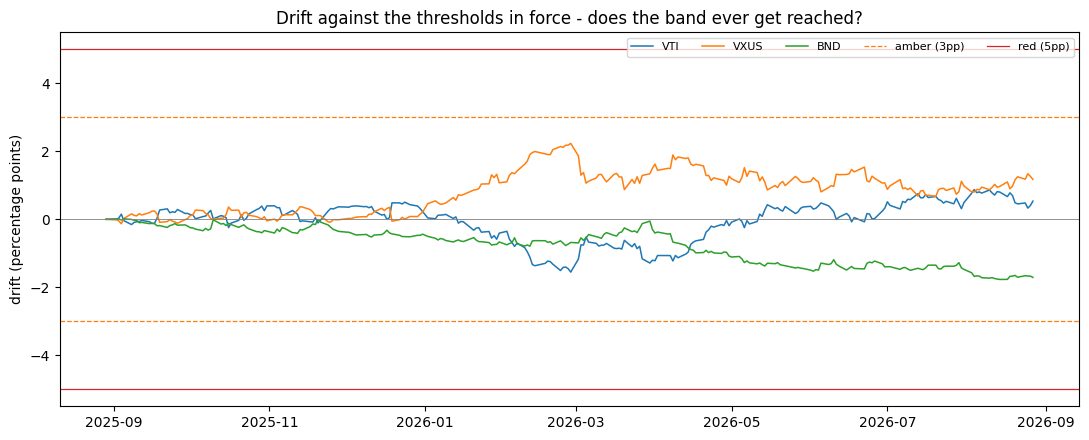

In [25]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for t in TICKERS:
    sub = drift_long[drift_long['ticker'] == t]
    ax.plot(sub['date'], sub['drift_pp'], linewidth=1.1, label=t)

for level, style, label in [(AMBER_PP, '--', 'amber'), (RED_PP, '-', 'red')]:
    for sign in (1, -1):
        ax.axhline(sign * level, linestyle=style, linewidth=0.9,
                   color='tab:orange' if label == 'amber' else 'tab:red',
                   label=f'{label} ({level:.0f}pp)' if sign == 1 else None)

ax.axhline(0, color='grey', linewidth=0.6)
ax.set_ylabel('drift (percentage points)')
ax.set_title('Drift against the thresholds in force - does the band ever get reached?')
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

### The alarm nobody has tested

A monitor that has never fired and a monitor that is broken produce the same
output: silence. Over a calm window they are indistinguishable, and "no alerts"
gets read as "nothing is wrong" when it might mean "nothing works".

So before drawing any conclusion from a quiet year, confirm the alarm is
physically capable of ringing. This injects a synthetic drift day past the red
line and checks the flag comes back red. It is a smoke test for the plumbing,
not a claim about the market.

In [26]:
checks = [
    outliers.stress_test_threshold(drift_long, shock_pp=6.0,
                                   amber=AMBER_PP, red=RED_PP),
    outliers.stress_test_threshold(drift_long, shock_pp=-5.5,
                                   amber=AMBER_PP, red=RED_PP),
    outliers.stress_test_threshold(drift_long, shock_pp=3.5,
                                   amber=AMBER_PP, red=RED_PP),
    outliers.stress_test_threshold(drift_long, shock_pp=0.4,
                                   amber=AMBER_PP, red=RED_PP),
]
stress = pd.DataFrame(checks)[['injected_pp', 'amber_pp', 'red_pp', 'flag', 'fires']]
print(stress.to_string(index=False))
print()

assert stress.loc[0, 'flag'] == 'red', 'a +6pp shock must read red'
assert stress.loc[1, 'flag'] == 'red', 'the rule must be symmetric in sign'
assert stress.loc[2, 'flag'] == 'amber', 'a 3.5pp shock sits in the amber band'
assert stress.loc[3, 'flag'] == 'green', 'a 0.4pp shock must stay green'
print('alarm wiring verified: the flag responds correctly at every level.')

 injected_pp  amber_pp  red_pp  flag  fires
         6.0       3.0     5.0   red   True
        -5.5       3.0     5.0   red   True
         3.5       3.0     5.0 amber  False
         0.4       3.0     5.0 green  False

alarm wiring verified: the flag responds correctly at every level.


The alarm works. That matters more than it sounds: it converts a year of silence
from *unknown* into *evidence*. The monitor is not broken - the portfolio simply
never drifted far enough to trip it.

In [27]:
# --- save the Stage 07 evidence ---
prof_path = PROC / f'drift_profile_{stamp}.csv'
sens_path = PROC / f'threshold_sensitivity_{stamp}.csv'
sus_path = PROC / f'return_outliers_{stamp}.csv'

profile.to_csv(prof_path)
sensitivity.to_csv(sens_path, index=False)
suspect[['date', 'ticker', 'close', 'ret',
         'ret_outlier_iqr', 'ret_outlier_z']].to_csv(sus_path, index=False)

for p in (prof_path, sens_path, sus_path):
    print('%-46s %6d bytes' % (p.name, p.stat().st_size))

drift_profile_20260829-1203.csv                   152 bytes
threshold_sensitivity_20260829-1203.csv           210 bytes
return_outliers_20260829-1203.csv                1609 bytes


### What Stage 07 changed, and what it deliberately did not

**Changed:** the monitor now has an outlier definition on both sides, stated in
`docs/outliers.md` - price-level faults judged per fund on daily returns, and
drift-level exceptions judged against a threshold that has now been priced
against a year of real data.

**Not changed: the 5pp red line stays where it is.** The tempting move after
seeing a year of green is to lower the threshold until something lights up. That
would be tuning the policy to flatter the output, which is backwards - the
threshold encodes what the firm principal considers worth acting on, and no
amount of quiet data changes that judgement. What the sweep does earn is the
right to *say* so: the line is high relative to this window, that is a deliberate
choice, and here is the number.

**The risk this leaves.** If the next year is not like this one, the first time
the alarm fires will be the first time anyone has seen it fire in production -
which is why the stress test above is committed alongside it rather than run
once and forgotten.

---

## Stage 08 - Exploratory Data Analysis

The full reasoning lives in `notebooks/eda.ipynb`. This section runs the three checks
that the rest of the pipeline depends on, and fails the run if any of them stops holding:

1. the date axis is business-daily, sorted, and free of duplicates and holes;
2. the drift is a trend rather than noise, which is what decides the Stage 09 feature set;
3. no column is silently degenerate before it becomes a feature.

In [28]:
# --- Stage 08 setup ---
from src import eda

daily_axis = weights_df.reset_index()[['date']]      # one row per trading day

# Profiling frame: drift_long plus the categorical columns, on a copy, so nothing
# Stage 07 built is mutated underneath it.
eda_frame = drift_long.copy()
eda_frame['flag'] = flag_drift(eda_frame['drift_pp'])
eda_frame['asset_class'] = np.where(eda_frame['ticker'] == 'BND', 'bond', 'equity')

print(f'profiling {len(eda_frame)} fund-days over {len(daily_axis)} trading days')
print(eda_frame['flag'].value_counts().to_string())

profiling 750 fund-days over 250 trading days
flag
green    750


In [29]:
# 1. Is the axis sound? Business-day grid, because a calendar grid reports every
#    weekend as a hole and buries the ten days that are genuinely absent.
axis = eda.time_axis_report(daily_axis, freq='B')

for key in ('n_unique_dates', 'is_sorted', 'n_duplicate_dates', 'n_missing_periods'):
    print(f'  {key:<20} {axis[key]}')
print('  absent business days:', ', '.join(str(d.date()) for d in axis['missing_periods']))

assert axis['is_sorted'],                  'dates are out of order - every lag downstream is wrong'
assert axis['n_duplicate_dates'] == 0,     'duplicate trading dates on the daily axis'
assert axis['n_missing_periods'] <= 12,    'more absent business days than a year of holidays'
print('axis OK')

  n_unique_dates       250
  is_sorted            True
  n_duplicate_dates    0
  n_missing_periods    10
  absent business days: 2025-09-01, 2025-11-27, 2025-12-25, 2026-01-01, 2026-01-19, 2026-02-16, 2026-04-03, 2026-05-25, 2026-06-19, 2026-07-03
axis OK


Ten absent business days, all US market holidays, against 114 absent *calendar* days.
That difference is the whole point of the check. The axis is business-daily, so a 7-row
rolling window in Stage 09 spans 9 calendar days on average and 11 across a holiday
weekend, and reindexing to `freq='D'` would insert 114 empty rows that dilute every
rolling statistic without raising an error. Stage 09 builds on this index as it is.

In [30]:
# 2. Trend or noise? Stage 07 established that neither threshold has ever fired.
#    A flag count cannot say whether that is a threshold set too high for the process,
#    or a trend that has not arrived yet. Those call for opposite responses.
trend = eda.drift_trend(drift_long, amber=AMBER_PP, red=RED_PP)
print(trend.to_string())

        n_obs  current_pp  rate_pp_per_year  corr_with_time  r_squared  years_to_amber  years_to_red
ticker                                                                                              
BND       250      -1.710            -1.686          -0.928      0.862           0.765         1.951
VTI       250       0.535             0.333           0.170      0.029           7.400        13.405
VXUS      250       1.174             1.353           0.643      0.414           1.349         2.827


In [31]:
# 3. Per-fund return profile - the evidence behind Stage 07 preferring IQR over z-score.
returns_profile = eda.return_profile(prices_clean)
print(returns_profile.to_string())

          n  mean_pct  std_pct  ann_vol_pct  min_pct  max_pct    skew  excess_kurtosis
ticker                                                                                
BND     249   -0.0066   0.2459       3.9028  -0.7999   0.5761 -0.2851           0.0880
VTI     249    0.0754   0.8244      13.0864  -2.6795   2.9293 -0.2283           1.1109
VXUS    249    0.0896   1.0726      17.0277  -3.7333   4.1143 -0.1299           1.9968


**Read these two tables together.** BND's drift correlates with time at -0.93: 86% of its
variation is a straight line, falling 1.69pp a year. VXUS rises 1.35pp a year. VTI is
flat. So the year of unbroken green is not a stationary process sitting safely below the
line, it is a one-way ratchet that has not travelled far enough yet. From today's drift,
BND is about 0.8 years from amber and VXUS about 1.4.

That changes the Stage 07 conclusion from a null result into a dated one, and it is the
single most useful sentence this project has produced for the principal.

The return profile is the other half. Excess kurtosis is measured against a normal
distribution, where 0 is the normal value. VXUS at 2.0 has heavier tails than normal,
which is exactly where a 3-sigma z-score assumes it knows the shape. BND at 0.07 is
near-normal. That is the evidence for Stage 07 making IQR the primary rule.

In [32]:
# 4. Anything degenerate before it becomes a feature?
flagged = eda.flag_columns(eda_frame)
print(flagged.to_string(index=False) if not flagged.empty
      else 'nothing flagged at the default thresholds')

# `flag` is 100% green, so it is a constant wearing a disguise. Assert that the check
# actually catches it: a flag_columns that silently returns nothing is worse than none.
assert (flagged['column'] == 'flag').any(), 'flag_columns missed the all-green column'
print()
print('confirmed: `flag` is a reporting column, not a Stage 09 feature')

column             issue  value  threshold
  flag dominant category  100.0       95.0

confirmed: `flag` is a reporting column, not a Stage 09 feature


In [33]:
# --- save the Stage 08 evidence ---
eda_stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')
trend_path = PROC / f'eda_drift_trend_{eda_stamp}.csv'
retprof_path = PROC / f'eda_return_profile_{eda_stamp}.csv'

trend.to_csv(trend_path)
returns_profile.to_csv(retprof_path)

for p in (trend_path, retprof_path):
    print('%-46s %6d bytes' % (p.name, p.stat().st_size))

eda_drift_trend_20260829-1203.csv                 227 bytes
eda_return_profile_20260829-1203.csv              255 bytes


### What Stage 08 changed

**Nothing about the data.** No values were altered, dropped or imputed. That is the
correct outcome for an EDA stage, and it is worth stating rather than leaving implied.

**Two things about what comes next.**

Stage 09 now has a feature list with a reason attached to each entry: first difference of
drift, rolling 21-day and 63-day slope, the equity-minus-bond return spread, and 21-day
realized volatility. It also has two prohibitions. Do not build calendar features, because
there is no seasonality in this series. Do not reindex to `freq='D'`, because the axis is
business-daily and doing so silently dilutes every rolling window.

Stage 10b now knows its split will look bad and why. A chronological split trains on the
low-drift half and tests on the high-drift half, so the test set is out of distribution by
construction. A random split would score better and would be leakage. The split stays
chronological and the write-up reports the drift range of each side next to the score.

---

## Stage 09 - Feature Engineering

The reasoning behind each feature is in `docs/features.md`, and the definitions are in
`README.md`. This section builds the matrix, checks it, and fails the run if any of
three things stops being true:

1. no feature reads data from after the row it describes;
2. no column reaches the modelling set while it is constant or mostly missing;
3. the target is far enough ahead to be worth predicting.

In [34]:
# --- Stage 09 setup ---
from src import features as fe

HORIZON = 21          # trading days; the choice is justified two cells below
TARGET = f'y_absdrift_fwd_{HORIZON}'

# One call, from the cleaned prices alone. `raw_reloaded` is passed only so
# `close_was_filled` can compare observed against filled closes.
features = fe.build_feature_matrix(prices_clean, TARGET_WEIGHTS,
                                   prices_raw=raw_reloaded, horizon=HORIZON)

print('feature matrix:', features.shape)
print('columns       :', ', '.join(c for c in features.columns if c not in
                                   ('date', 'ticker', 'weight', 'target_weight')))
features.head()

feature matrix: (750, 21)
columns       : drift_pp, abs_drift, drift_rel, abs_drift_rel, drift_chg_1, drift_chg_5, drift_slope_21, drift_slope_63, ret_1, vol_21, eq_bond_spread_21, ticker_BND, ticker_VTI, ticker_VXUS, ticker_target, close_was_filled, y_absdrift_fwd_21


,date,ticker,weight,target_weight,drift_pp,abs_drift,drift_rel,abs_drift_rel,drift_chg_1,drift_chg_5,...,drift_slope_63,ret_1,vol_21,eq_bond_spread_21,ticker_BND,ticker_VTI,ticker_VXUS,ticker_target,close_was_filled,y_absdrift_fwd_21
0,2025-08-29,BND,0.100000,0.1,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,1,0,0,0.1,0,0.200645
1,2025-09-02,BND,0.100140,0.1,0.014004,0.014004,0.140043,0.140043,0.014004,NaN,...,NaN,-0.005420,NaN,NaN,1,0,0,0.1,0,0.247308
2,2025-09-03,BND,0.100116,0.1,0.011644,0.011644,0.116437,0.116437,-0.002361,NaN,...,NaN,0.003270,NaN,NaN,1,0,0,0.1,0,0.251933
3,2025-09-04,BND,0.099806,0.1,-0.019356,0.019356,-0.193559,0.193559,-0.031000,NaN,...,NaN,0.003802,NaN,NaN,1,0,0,0.1,0,0.287480
4,2025-09-05,BND,0.100146,0.1,0.014556,0.014556,0.145557,0.145557,0.033912,NaN,...,NaN,0.004735,NaN,NaN,1,0,0,0.1,0,0.335618


In [35]:
# Why 21 days and not 1. Today's absolute drift against its own future value:
rows = []
base = fe.drift_features(fe.drift_panel(prices_clean, TARGET_WEIGHTS),
                         TARGET_WEIGHTS, slope_windows=())
for h in (1, 5, 21, 63):
    frame = fe.make_forward_target(base, horizon=h)
    pair = frame[['abs_drift', f'y_absdrift_fwd_{h}']].dropna()
    rows.append({'horizon_trading_days': h,
                 'r_with_todays_level': pair.iloc[:, 0].corr(pair.iloc[:, 1]),
                 'usable_rows': len(pair)})
horizon_choice = pd.DataFrame(rows).set_index('horizon_trading_days').round(3)
print(horizon_choice.to_string())

assert horizon_choice.loc[1, 'r_with_todays_level'] > 0.95, \
    'a 1-day horizon should be near-trivially predictable; if it is not, the trend broke'
assert horizon_choice.loc[HORIZON, 'r_with_todays_level'] < 0.80, \
    'the chosen horizon must leave something for the other features to explain'

                      r_with_todays_level  usable_rows
horizon_trading_days                                  
1                                   0.979          747
5                                   0.912          735
21                                  0.687          687
63                                  0.230          561


**Why the horizon is a decision and not a default.** Today's absolute drift predicts
tomorrow's at 0.98. A model trained on a one-day horizon would score above 0.95 by
answering "the same as today" and would have learned nothing. That is Stage 08's trend
finding arriving as a modelling constraint: a trended series is trivially predictable
one step ahead, and the triviality scales with how short the step is.

At 21 trading days the same correlation falls to 0.69, which leaves room for the other
features, and a month is enough warning for the principal to act on. The two assertions
above hold the choice in place: if a future pull breaks either bound, the horizon needs
revisiting rather than silently becoming a worse question.

In [36]:
# What each feature is worth, and what it costs. Coverage and distinctness come
# BEFORE the correlation on purpose: a promising number on a nearly empty column
# is not a result.
CANDIDATES = fe.MODEL_FEATURES + ['drift_slope_63', 'ticker_target', 'close_was_filled']
report = fe.feature_report(features, CANDIDATES, TARGET, group='ticker')
print(report.to_string())

                   pct_missing  n_unique     mean      std  n_pairs  corr_with_target  corr_BND  corr_VTI  corr_VXUS
feature                                                                                                             
abs_drift                  0.0       748   0.6770   0.5317      687            0.6874    0.8635    0.2738     0.6561
abs_drift_rel              0.0       748   3.7307   4.3784      687            0.6183    0.8635    0.2738     0.6561
drift_chg_1                0.4       747   0.0000   0.1120      684           -0.0097   -0.0353   -0.0565     0.0336
drift_chg_5                2.0       735  -0.0000   0.2323      672           -0.0238   -0.0913   -0.1286     0.0809
drift_slope_21             8.0       690   0.0000   6.0479      627           -0.1091   -0.2475   -0.3865     0.1570
ret_1                      0.4       738   0.0005   0.0079      684           -0.0291   -0.0531   -0.0848     0.0013
vol_21                     8.4       687  11.2574   6.5627      

**The row that matters most is `vol_21`.** Pooled it correlates with the target at
+0.036, which reads as irrelevant. Per fund it is **+0.57 for BND and -0.23 for VTI**.
The pooled number is not a weak signal, it is two opposite signals cancelling.

That is the concrete payoff of the one-hot encoding. A model without the fund identity
would see +0.036, drop volatility, and be wrong about two funds at once. It is also the
sharpest illustration in this project of why correlation is a screen rather than a
ranking.

`abs_drift` at +0.689 is the strongest single feature and largely restates the trend.
`drift_chg_1` at -0.010 is the honest failure: Stage 08's written instruction put the
first difference at the top of the list, and it did not work. The information Stage 08
was pointing at lives in the smoothed rate, `drift_slope_21`, not the raw one. The
feature stays in the matrix as a recorded negative result rather than being deleted.

In [37]:
# 1. Does any feature read the future? Build on the full history, build again on a
#    truncated history, compare the overlap. A causal feature is identical in both.
#    `with_target=False` because a forward target is SUPPOSED to change.
audit = fe.assert_no_lookahead(
    lambda frame: fe.build_feature_matrix(frame, TARGET_WEIGHTS, with_target=False),
    prices_clean, fe.MODEL_FEATURES)

for key, value in audit.items():
    print(f'  {key:<18} {value}')
print('no look-ahead in any of the %d modelling features' % len(fe.MODEL_FEATURES))

  cut_date           2026-05-12 00:00:00
  rows_compared      528
  features_checked   11
no look-ahead in any of the 11 modelling features


In [38]:
# A test that never fails is not a test. Break one feature deliberately and confirm
# the audit catches it. A CENTRED window is the classic leak: it reads as an ordinary
# smoother and quietly sees ten days into its own future.
def _leaky(frame):
    out = fe.build_feature_matrix(frame, TARGET_WEIGHTS, with_target=False)
    out['drift_slope_21'] = (out.groupby('ticker')['drift_pp']
                                .transform(lambda s: s.rolling(21, center=True).mean()))
    return out


try:
    fe.assert_no_lookahead(_leaky, prices_clean, ['drift_slope_21'])
    raise RuntimeError('the look-ahead audit failed to catch a known leak')
except AssertionError as exc:
    print('leak correctly caught:')
    print(' ', exc)

leak correctly caught:
  look-ahead detected in 'drift_slope_21': truncating the future changed which past rows are even defined (30 NaN with the full history, 60 without it). A window that needs rows after t is not causal.


**Why this check earns its place in the pipeline.** A leaked feature does not raise an
error. It raises an R-squared, and everything about the code and the output continues to
look correct. `center=True` is a one-word change that a code review reads as a smoothing
preference and that lets every row see ten days of its own future. In Stage 10b it would
produce a test score that cannot be reproduced in production.

Running the audit here means a future edit that introduces a leak fails this notebook
rather than improving the model.

In [39]:
# 2. Does anything degenerate reach the modelling set? Stage 08's own gate, plus the
#    constant check that gate is known to miss.
gate = eda.flag_columns(features[CANDIDATES])
print(gate.to_string(index=False) if not gate.empty else 'gate: nothing flagged')

constants = [c for c in CANDIDATES if features[c].nunique(dropna=True) <= 1]
print('constant columns:', constants or 'none')

for column in fe.MODEL_FEATURES:
    assert features[column].nunique(dropna=True) > 1, f'{column} is constant'
    assert features[column].isna().mean() <= 0.20, f'{column} is more than 20% missing'
print('all %d modelling features pass the Stage 08 gate' % len(fe.MODEL_FEATURES))

        column            issue  value  threshold
drift_slope_63 high missingness   24.8       20.0
constant columns: ['close_was_filled']
all 11 modelling features pass the Stage 08 gate


**What the gate caught.** `drift_slope_63` at 24.70% missing, against Stage 08's 20%
threshold. It costs a quarter of the panel and returns a pooled correlation of -0.001,
so it is excluded. `ticker_freq` is not built here at all: with 251/251/251 rows per
fund, frequency encoding is arithmetically a constant, which the homework notebook
demonstrates rather than asserts.

**What it missed, and why that is worth knowing.** `close_was_filled` is constant at
zero on this pull, and `flag_columns` does not flag it. Its near-zero-variance rule
divides by the mean and skips any column whose mean is zero. The blind spot is narrow
and precise, all-zero columns only, and the explicit `nunique` assertions above cover it.

**`close_was_filled` is still built and still saved.** It is excluded from the modelling
set while it is constant, which is the correct handling today. It stays in the pipeline
because it costs one merge, it is verified to fire on a damaged copy in the homework
notebook, and on the day a vendor gap appears it is the only column that can tell a
model which rows are estimates rather than observations. This closes the item
`README.md` has carried open since Stage 06.

In [40]:
# --- save the Stage 09 artifacts ---
feat_stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')

model_ready = features[['date', 'ticker'] + fe.MODEL_FEATURES + [TARGET]].dropna()

full_path = PROC / f'features_full_{feat_stamp}.parquet'
ready_path = PROC / f'features_model_ready_{feat_stamp}.parquet'
rep_path = PROC / f'feature_report_{feat_stamp}.csv'

write_df(features, full_path)
write_df(model_ready, ready_path)
report.to_csv(rep_path)

lost = len(features) - len(model_ready)
print(f'full matrix : {features.shape}')
print(f'model ready : {model_ready.shape}  ({lost} rows lost to windows and the '
      f'{HORIZON}-day forward target)')
print()
for p in (full_path, ready_path, rep_path):
    print('%-52s %7d bytes' % (p.name, p.stat().st_size))

# Round trip, same as every other artifact in this project.
back = read_df(ready_path)
assert back.shape == model_ready.shape, 'round trip changed the shape'
print('round trip verified')

full matrix : (750, 21)
model ready : (624, 14)  (126 rows lost to windows and the 21-day forward target)

features_full_20260829-1203.parquet                    97433 bytes
features_model_ready_20260829-1203.parquet             62999 bytes
feature_report_20260829-1203.csv                         913 bytes
round trip verified


### What Stage 09 changed, and what it deliberately did not

**Eleven features, each traceable to a finding.** Not one was invented because it was
easy to compute. `abs_drift_rel` comes from Stage 07's open unit problem, the rate
features from Stage 08's trend, `vol_21` from Stage 08's volatility clustering,
`eq_bond_spread_21` from the mechanism Stage 08 identified, the one-hot encoding from
Stage 08's 251/251/251 categorical profile, and `close_was_filled` from this README's own
open item. That lineage is the deliverable; the code is the easy half.

**A unit result worth taking to the principal.** Drift measured relative to each fund's
target predicts its own future at **0.906**, against **0.689** for the percentage-point
formulation. Within a fund the two are the same number rescaled, so this is not a
better feature, it is evidence that the relative unit is the more coherent description
of what the portfolio does. Stage 07 raised the unit question and left it open. Stage 09
did not close it, because changing the unit changes the policy, but it is no longer an
open question without evidence attached.

**One prediction that failed, kept on the record.** Stage 08 said to build the first
difference of drift. Built, measured at -0.010, and reported. The idea was right and the
implementation was too raw: the signal is in `drift_slope_21`, not `drift_chg_1`.

**Nothing was scaled, and that is deliberate.** Standardising features here would fit the
scaler on the whole history, including the rows Stage 10b will hold out as a test set.
That is the same class of error as the centred window above, and the look-ahead audit
would *not* catch it, because it happens after the features are built. Scaling belongs
inside the split.

**Handoff to Stage 10.** `data/processed/features_model_ready_<stamp>.parquet`: 11
features, one target, complete rows only. Split chronologically, as Stage 08 required,
and expect a worse score than a random split would give, because a random split on a
trended series leaks.